# Transplant Analysis
- Dependent: Protein creatinine ratio, Albumin excretion 24h, Protein excretion 24h, Proteinuria_spot (qualitative present/absent), Proteinuria_24h (qualitative present/absent), Creatinine, Cystatin_C, eGFR_sCr, eGFR_Cystatin, CKD (qualitative, present/absent, which means GFR less than 60 based on Cystatin C)

In [5]:
import math
import subprocess
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is available even in a fresh environment
try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio

data_all = pd.read_csv('renal_all.csv')
data_notransplant = pd.read_csv('renal_notransplant.csv')
data_transplant = pd.read_csv('renal_transplant.csv')

data_all.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 35.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]


,DOS,VID,Sex,MMAtype0123,ID,Age,Sex_M_F,Transplant,TransplantType,Protein_Creatinine_Ratio,...,Microalbuminuria,Proteinuria_24h,Creatinine,Cystatin_C,eGFR_SCr,eGFR_CystatinC,CKD,PTH_pg_ml,Two_Truncating,CKD_StageCys
0,6/16/2011,VID.10286,0,0,1,5.750000,M,0,,,...,0,0,0.79,1.28,54.160506,56.1753128707481,1,,0,3
1,6/19/2014,VID.10286,0,0,1,8.758333,M,0,,.296,...,1,0,2.38,2.01,21.552353,36.9047656802983,1,115.8,0,3
2,8/20/2007,VID.10094,1,1,2,24.516667,F,0,,.158,...,1,1,0.93,,87.737906,,,,0,
3,8/23/2011,VID.10094,1,1,2,28.525000,F,0,,.162,...,,,0.97,.94,81.360607,89.25,0,,0,2
4,6/12/2017,VID.10149,1,1,3,11.813889,F,0,,,...,0,0,0.69,1.02,87.986957,69.3986818745387,0,44.4,0,2


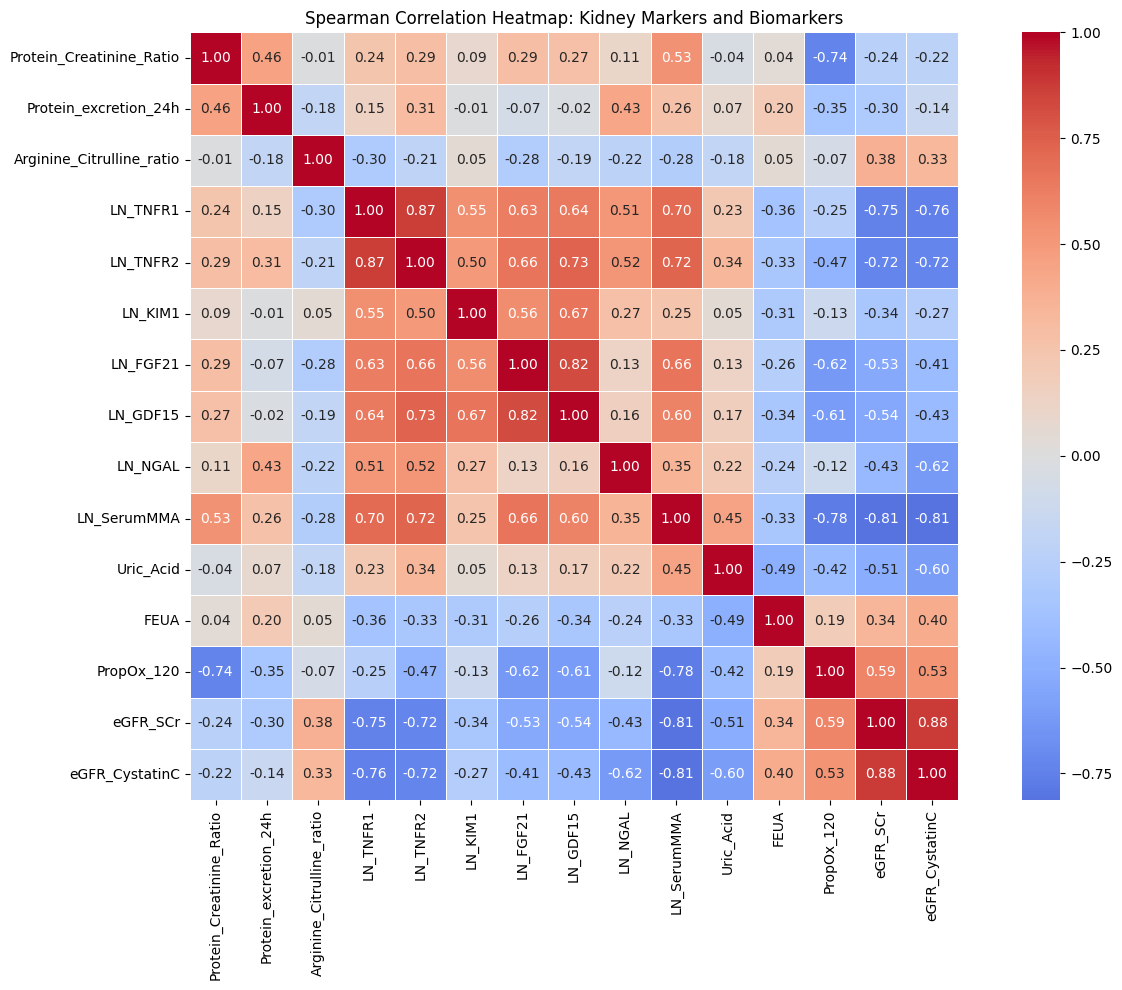

PropOx_120                   0.697917
Protein_excretion_24h        0.572917
LN_GDF15                     0.385417
Protein_Creatinine_Ratio     0.375000
LN_SerumMMA                  0.302083
LN_NGAL                      0.239583
LN_FGF21                     0.229167
FEUA                         0.229167
LN_TNFR1                     0.208333
LN_TNFR2                     0.187500
eGFR_CystatinC               0.166667
LN_KIM1                      0.156250
Uric_Acid                    0.114583
Arginine_Citrulline_ratio    0.052083
eGFR_SCr                     0.000000
LN_RBP4                      0.000000
LN_TGFb1                     0.000000
dtype: float64

In [6]:
# Heatmap for selected clinical + biomarker variables
heatmap_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_120',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

# Optional sparse biomarkers are intentionally excluded from the default plot:
# LN_RBP4, LN_TGFb1

heatmap_df = data_all.copy()
for col in heatmap_vars:
    heatmap_df[col] = pd.to_numeric(heatmap_df[col], errors='coerce')

corr_matrix = heatmap_df[heatmap_vars].corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title('Spearman Correlation Heatmap: Kidney Markers and Biomarkers')
plt.tight_layout()
plt.show()

# Quick completeness check for sparse features
missing_summary = heatmap_df[heatmap_vars + ['LN_RBP4', 'LN_TGFb1']].isna().mean().sort_values(ascending=False)
missing_summary

Kept targets for multi-output modeling: ['Protein_excretion_24h', 'Albumin_excretion_24h', 'Protein_Creatinine_Ratio', 'Cystatin_C', 'eGFR_CystatinC', 'Creatinine', 'eGFR_SCr']
Rows used for model: 96
Mean CV R2: -8.658 +/- 16.370
Mean CV RMSE (macro): 71.733
Mean CV MAE (macro): 21.965


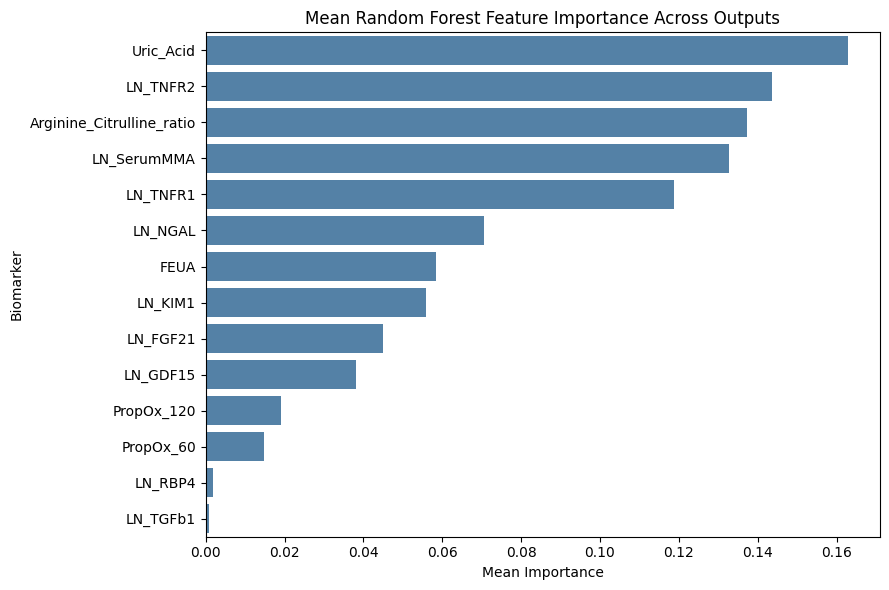

,feature,mean_importance
10,Uric_Acid,0.162884
2,LN_TNFR2,0.143560
0,Arginine_Citrulline_ratio,0.137404
9,LN_SerumMMA,0.132763
1,LN_TNFR1,0.118703
6,LN_NGAL,0.070498
11,FEUA,0.058384
3,LN_KIM1,0.056008
4,LN_FGF21,0.044950
5,LN_GDF15,0.038086


In [7]:
# Multi-output modeling: predict dependent variables from selected biomarkers
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

# Dependent variables from notebook description (using dataset column names)
dependent_vars = [
    'Protein_Creatinine_Ratio',
    'Albumin_excretion_24h',
    'Protein_excretion_24h',
    'Creatinine',
    'Cystatin_C',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

# Independent biomarkers requested
independent_vars = [
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_RBP4',
    'LN_TGFb1',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_60',
    'PropOx_120',
]

model_df = data_all[independent_vars + dependent_vars].copy()

# Coerce numeric
for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Drop targets that are mostly missing to keep a stable multi-output target matrix
target_missing = model_df[dependent_vars].isna().mean().sort_values(ascending=False)
kept_targets = target_missing[target_missing <= 0.60].index.tolist()

# Keep rows with at least one target present, then impute Y so multi-output model can run
model_df = model_df.loc[model_df[kept_targets].notna().any(axis=1)].copy()
X = model_df[independent_vars]
Y = model_df[kept_targets]

x_preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), independent_vars),
    ],
    remainder='drop'
)

y_imputer = SimpleImputer(strategy='median')
Y_imputed = pd.DataFrame(
    y_imputer.fit_transform(Y),
    columns=kept_targets,
    index=Y.index,
)

rf = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )
)

pipeline = Pipeline([
    ('x_preprocess', x_preprocess),
    ('rf_multi', rf),
])

# Evaluation: multi-output R2 + error-based metrics
def rmse_macro(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred, multioutput='uniform_average'))

def mae_macro(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred, multioutput='uniform_average')

scoring = {
    'r2': 'r2',
    'rmse_macro': make_scorer(rmse_macro, greater_is_better=False),
    'mae_macro': make_scorer(mae_macro, greater_is_better=False),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipeline,
    X,
    Y_imputed,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

print('Kept targets for multi-output modeling:', kept_targets)
print('Rows used for model:', len(X))
print(f"Mean CV R2: {cv_results['test_r2'].mean():.3f} +/- {cv_results['test_r2'].std():.3f}")
print(f"Mean CV RMSE (macro): {-cv_results['test_rmse_macro'].mean():.3f}")
print(f"Mean CV MAE (macro): {-cv_results['test_mae_macro'].mean():.3f}")

# Fit final model on all available rows
pipeline.fit(X, Y_imputed)

# Aggregate feature importance across all output models
feature_names = independent_vars
all_importances = np.array([
    est.feature_importances_ for est in pipeline.named_steps['rf_multi'].estimators_
])
mean_importance = all_importances.mean(axis=0)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_importance': mean_importance,
}).sort_values('mean_importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x='mean_importance', y='feature', color='steelblue')
plt.title('Mean Random Forest Feature Importance Across Outputs')
plt.xlabel('Mean Importance')
plt.ylabel('Biomarker')
plt.tight_layout()
plt.show()

importance_df

In [8]:
# -----------------------------
# Grouped comparison setup
# -----------------------------
comparison_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Albumin_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_60',
    'PropOx_120',
    'Creatinine',
    'Cystatin_C',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

plot_df = data_all.copy()
for col in comparison_vars:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

# Robust normalization for grouping columns
plot_df['Transplant_norm'] = pd.to_numeric(plot_df['Transplant'], errors='coerce')
plot_df['TransplantType_norm'] = (
    plot_df['TransplantType']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
    .replace({'': 'Unknown', 'nan': 'Unknown', 'None': 'Unknown'})
)

# Build a clear group label for comparison
plot_df['Group'] = np.where(
    plot_df['Transplant_norm'] == 0,
    'Non-Transplant',
    'Transplant-' + plot_df['TransplantType_norm']
)

# Standardize common transplant labels
plot_df['Group'] = plot_df['Group'].replace({
    'Transplant-l': 'Transplant-L',
    'Transplant-lk': 'Transplant-LK',
    'Transplant-k': 'Transplant-K',
})

group_order = [
    'Non-Transplant',
    'Transplant-L',
    'Transplant-LK',
    'Transplant-K',
    'Transplant-Unknown',
]
# Keep observed groups and append any additional unexpected groups
observed_groups = plot_df['Group'].dropna().unique().tolist()
group_order = [g for g in group_order if g in observed_groups] + [
    g for g in observed_groups if g not in group_order
]

print('Groups available and sample size:')
print(plot_df['Group'].value_counts(dropna=False))

Groups available and sample size:
Group
Non-Transplant    96
Name: count, dtype: int64


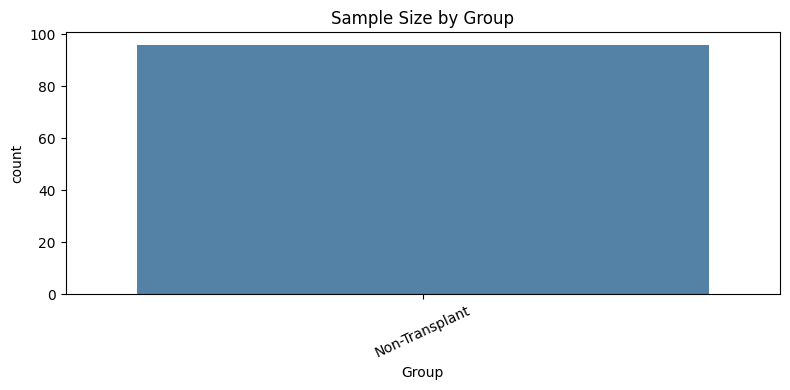

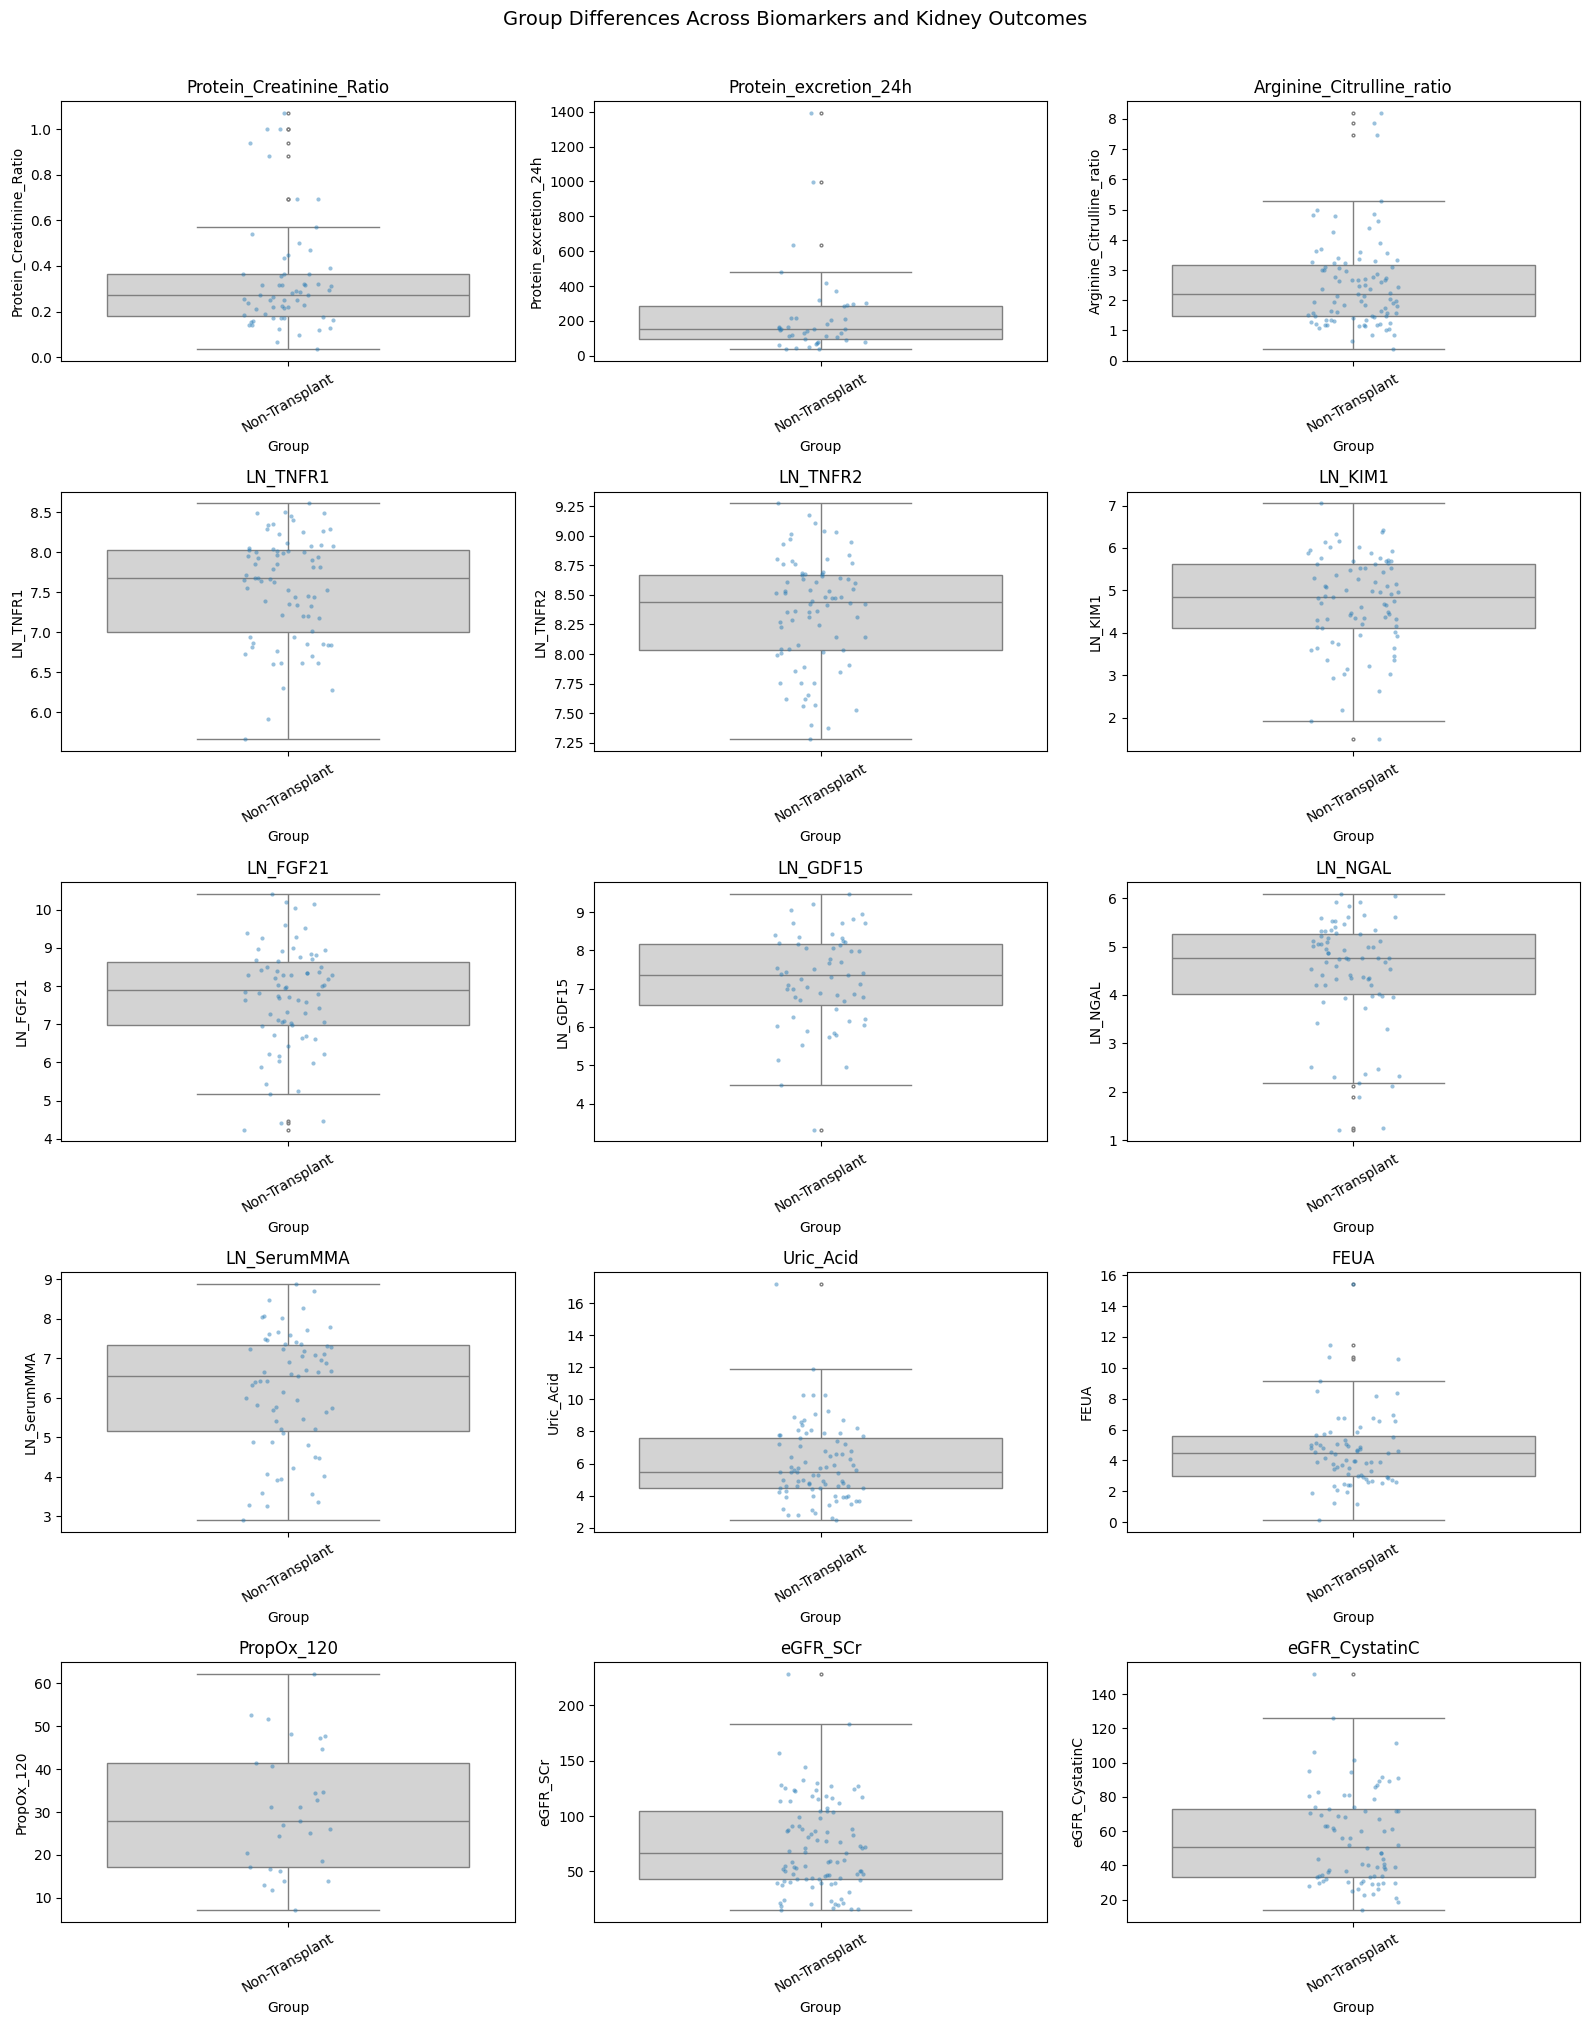

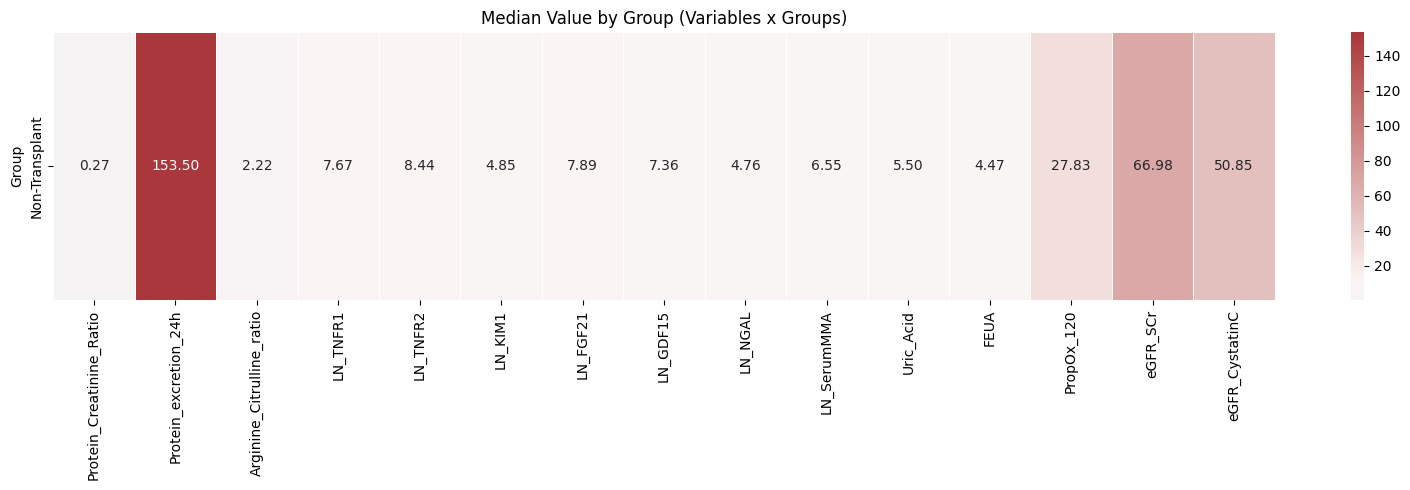

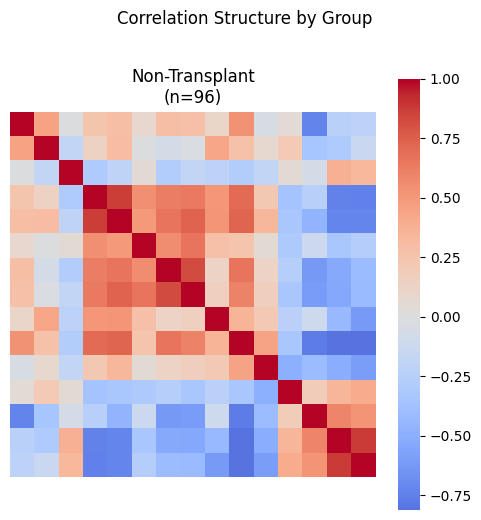

In [9]:
# -----------------------------
# Multi-graph comparisons across groups
# -----------------------------

# 1) Group size bar chart
plt.figure(figsize=(8, 4))
sns.countplot(data=plot_df, x='Group', order=group_order, color='steelblue')
plt.title('Sample Size by Group')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# 2) Boxplots for key variables (same visual style across groups)
key_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_120',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

ncols = 3
nrows = int(np.ceil(len(key_vars) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    sns.boxplot(
        data=plot_df,
        x='Group',
        y=var,
        order=group_order,
        ax=axes[i],
        color='lightgray',
        fliersize=2,
    )
    sns.stripplot(
        data=plot_df,
        x='Group',
        y=var,
        order=group_order,
        ax=axes[i],
        color='tab:blue',
        alpha=0.45,
        size=3,
    )
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Group Differences Across Biomarkers and Kidney Outcomes', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# 3) Median heatmap by group (good high-level summary)
median_table = plot_df.groupby('Group')[key_vars].median(numeric_only=True).reindex(group_order)

plt.figure(figsize=(16, 5))
sns.heatmap(
    median_table,
    cmap='vlag',
    center=np.nanmedian(median_table.values),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
)
plt.title('Median Value by Group (Variables x Groups)')
plt.tight_layout()
plt.show()

# 4) Group-specific correlation heatmaps (same method as your current approach)
corr_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_120',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

n_panels = len(group_order)
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 5), squeeze=False)

for idx, group_name in enumerate(group_order):
    grp = plot_df.loc[plot_df['Group'] == group_name, corr_vars]
    corr = grp.corr(method='spearman')
    sns.heatmap(
        corr,
        ax=axes[0, idx],
        cmap='coolwarm',
        center=0,
        cbar=(idx == n_panels - 1),
        square=True,
        xticklabels=False,
        yticklabels=False,
    )
    axes[0, idx].set_title(f'{group_name}\n(n={len(grp)})')

plt.suptitle('Correlation Structure by Group', y=1.03)
plt.tight_layout()
plt.show()

In [14]:
# -----------------------------
# Sparse-data-friendly group comparison
# -----------------------------
# Pairwise comparisons robust to small samples:
#   1) Cliff's delta (effect size)
#   2) Permutation p-value on median difference

from scipy.stats import permutation_test

# Choose reference group robustly
if 'Non-Transplant' in group_order:
    reference_group = 'Non-Transplant'
else:
    # Fallback: largest group as reference if Non-Transplant label is absent
    reference_group = plot_df['Group'].value_counts().index[0]

comparison_groups = [g for g in group_order if g != reference_group]


def cliffs_delta(x, y):
    """Cliff's delta: probability(x>y) - probability(x<y)."""
    x = np.asarray(x)
    y = np.asarray(y)
    gt = np.sum(x[:, None] > y[None, :])
    lt = np.sum(x[:, None] < y[None, :])
    return (gt - lt) / (len(x) * len(y))


def cliff_magnitude(delta):
    ad = abs(delta)
    if ad < 0.147:
        return 'negligible'
    if ad < 0.33:
        return 'small'
    if ad < 0.474:
        return 'medium'
    return 'large'


def median_diff_stat(a, b, axis=0):
    return np.nanmedian(a, axis=axis) - np.nanmedian(b, axis=axis)


results = []
skipped = []
for var in key_vars:
    x_ref = plot_df.loc[plot_df['Group'] == reference_group, var].dropna().values

    for grp in comparison_groups:
        x_grp = plot_df.loc[plot_df['Group'] == grp, var].dropna().values

        # Sparse-friendly threshold
        if len(x_ref) >= 2 and len(x_grp) >= 2:
            delta = cliffs_delta(x_grp, x_ref)

            # Use exact permutation when feasible; otherwise Monte Carlo resampling
            n_total = len(x_grp) + len(x_ref)
            n_resamples = 2000 if n_total > 25 else 10000

            perm = permutation_test(
                (x_grp, x_ref),
                statistic=median_diff_stat,
                permutation_type='independent',
                alternative='two-sided',
                n_resamples=n_resamples,
                random_state=42,
            )

            results.append({
                'Variable': var,
                'Comparison': f'{grp} vs {reference_group}',
                'n_group': len(x_grp),
                'n_reference': len(x_ref),
                'Median_group': float(np.nanmedian(x_grp)),
                'Median_reference': float(np.nanmedian(x_ref)),
                'Median_diff': float(np.nanmedian(x_grp) - np.nanmedian(x_ref)),
                'Cliffs_delta': float(delta),
                'Effect_magnitude': cliff_magnitude(delta),
                'Permutation_p': float(perm.pvalue),
            })
        else:
            skipped.append((var, grp, len(x_grp), len(x_ref)))

sparse_compare_df = pd.DataFrame(results)

print(f'Reference group: {reference_group}')
print('Groups considered:', comparison_groups)

if sparse_compare_df.empty:
    print('No pairwise tests could run with current missingness and grouping.')
    print('First skipped examples (var, group, n_group, n_reference):')
    print(skipped[:10])
else:
    sparse_compare_df = sparse_compare_df.sort_values(
        ['Permutation_p', 'Cliffs_delta'],
        ascending=[True, False]
    )

    print('Top sparse-data-friendly group differences:')
    display(sparse_compare_df.head(20))

sparse_compare_df

Reference group: Non-Transplant
Groups considered: []
No pairwise tests could run with current missingness and grouping.
First skipped examples (var, group, n_group, n_reference):
[]


""
